ques1
Simulate the forward diffusion process by writing a Python function that takes a grayscale image (use any small PNG or JPEG) and adds Gaussian noise to it for 10 steps, saving each noisy image to disk.

In [ ]:
import cv2
import numpy as np

def forward_diffusion(image_path, steps=10):
    # Load grayscale image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Error: Image not found!")
        return

    current_img = img.copy()

    # Save original image
    cv2.imwrite("step_0_original.jpg", current_img)

    for step in range(1, steps + 1):
        # Generate Gaussian noise
        noise = np.random.normal(0, 25, current_img.shape)

        # Add noise
        noisy_img = current_img + noise

        # Keep pixel values between 0 and 255
        noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

        # Save noisy image
        cv2.imwrite(f"step_{step}.jpg", noisy_img)

        current_img = noisy_img

    print("Forward diffusion completed successfully!")

# Example usage
forward_diffusion("/content/download.jpeg")

Forward diffusion completed successfully!


ques :2.
Write a Python script that takes a noisy image and applies a simple denoising filter (like median blur or Gaussian blur) to approximate the reverse diffusion process, then compare the denoised output visually with the original image.<br><br><em><strong>Hint:</strong> Use OpenCV's cv2.medianBlur() or cv2.GaussianBlur() for denoising.</em>

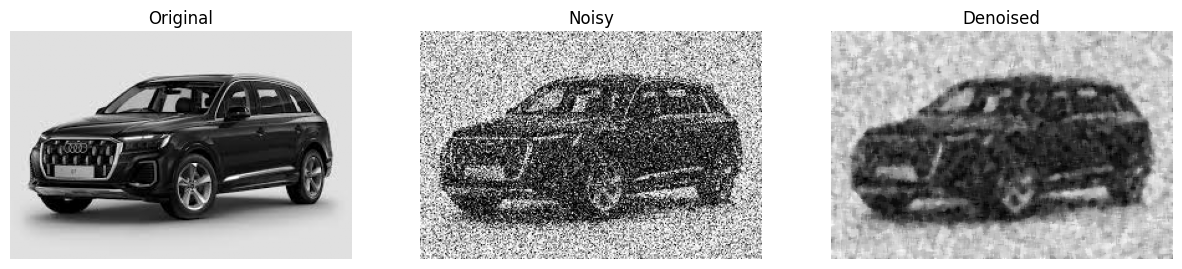

Denoised image saved as 'denoised_image.jpg'


In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load original and noisy images in grayscale
original = cv2.imread("/content/download.jpeg", cv2.IMREAD_GRAYSCALE)
noisy = cv2.imread("step_10.jpg", cv2.IMREAD_GRAYSCALE)

# Check if images loaded successfully
if original is None or noisy is None:
    print("Error: Could not load one or both images.")
else:
    # Apply median blur for denoising
    denoised = cv2.medianBlur(noisy, 5)

    # Save denoised image
    cv2.imwrite("denoised_image.jpg", denoised)

    # Display images
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(noisy, cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(denoised, cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

    plt.show()

    print("Denoised image saved as 'denoised_image.jpg'")

Ques 3: Use the Stable Diffusion web demo (https://stablediffusionweb.com/ or similar) to generate an image from the text prompt: 'A futuristic cricket stadium during IPL finals, night view, neon lights'. Save the generated image and write 2-3 lines describing how the AI interpreted your prompt.


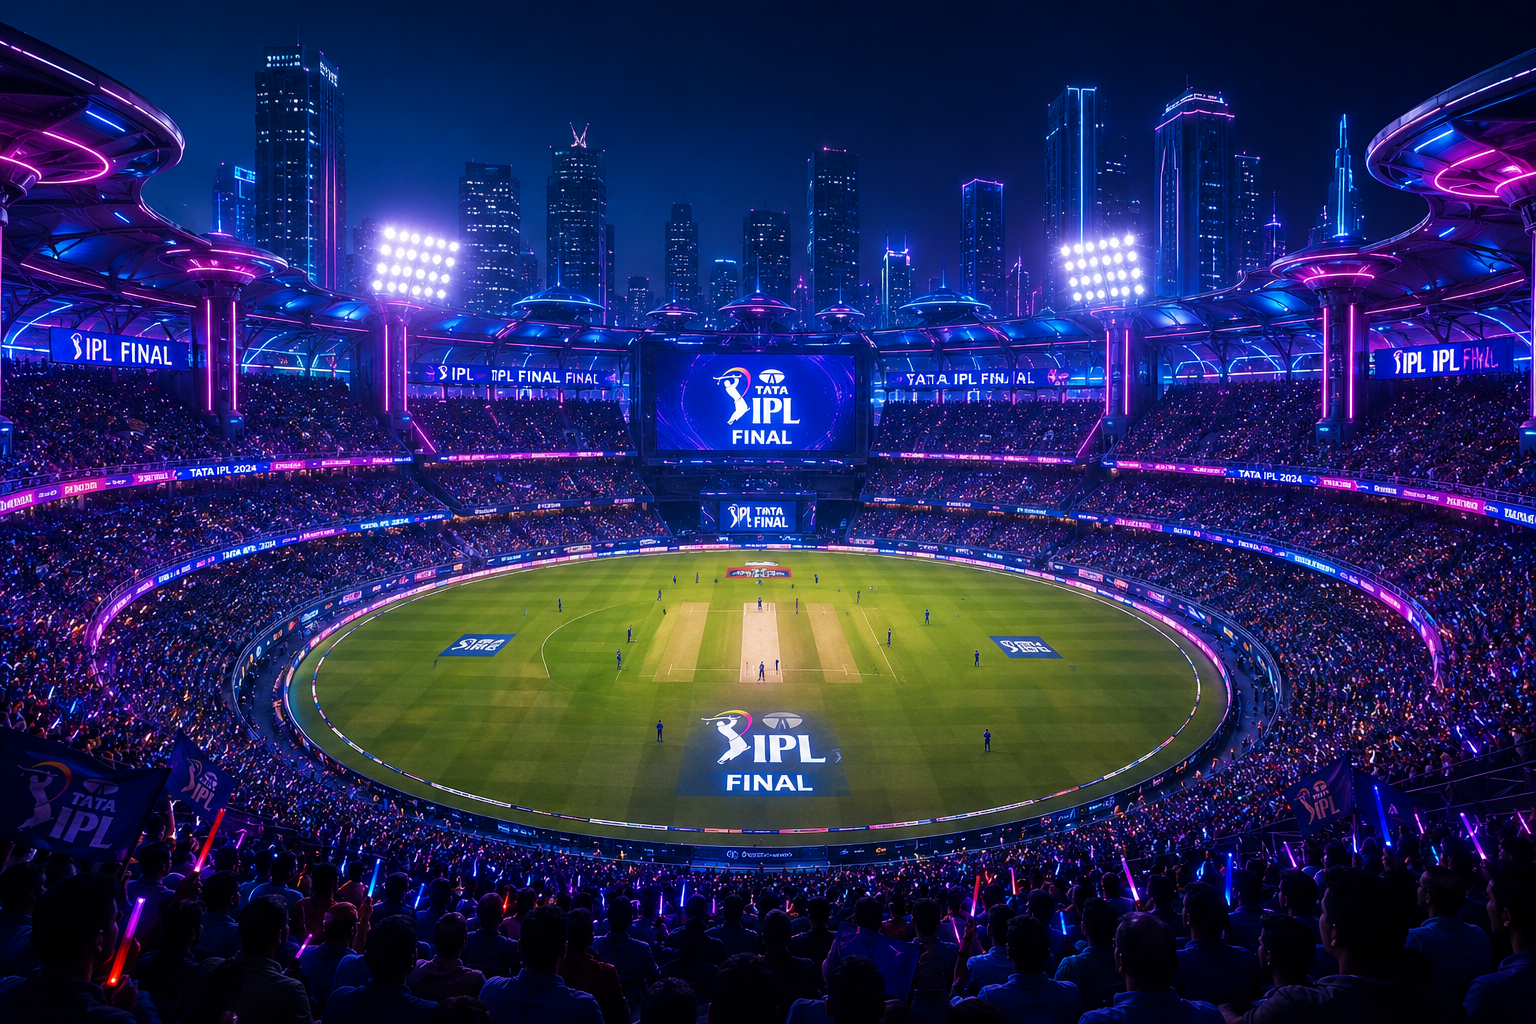

Ques 4: Research and list two real-world apps or websites (other than art generators) that use diffusion models for image inpainting or super-resolution. For each, briefly describe the user scenario where diffusion is applied.


[Adobe Photoshop](https://www.adobe.com/products/photoshop.html?utm_source=chatgpt.com) (Generative Fill)** | Image inpainting       | Users can remove unwanted objects, extend image backgrounds, or replace parts of a photo by selecting an area and providing a text prompt. The diffusion-based model generates realistic content that blends with the surrounding image.
[Clipdrop](https://clipdrop.co/?utm_source=chatgpt.com) (Image Upscaler)**                                  | Image super-resolution | Users upload a low-resolution or blurry image, and the AI enhances details and increases resolution while preserving textures and edges. Diffusion-based restoration techniques help reconstruct realistic high-quality images. ([ScienceDirect][2])     |

[1]: https://www.codesota.com/building-blocks/image-to-image?utm_source=chatgpt.com "Image Transformation | AI Building Blocks | CodeSOTA | CodeSOTA"
[2]: https://www.sciencedirect.com/science/article/pii/S0925231224016825?utm_source=chatgpt.com "Diffusion models for image super-resolution: State-of-the-art and future directions - ScienceDirect"


ques 5: List two possible risks or ethical concerns when using text-to-image models like Stable Diffusion for social media content, and suggest one way developers can reduce each risk.


| **Risk/Ethical Concern**                          | **Description**                                                                                                               | **Possible Solution**                                                                                                        |

| **1. Deepfakes and Misinformation**               | AI-generated images can create fake events or realistic images of people, which may spread false information on social media. | Developers can add **AI-generated watermarks and content detection systems** to help users identify synthetic images.        |
| **2. Copyright and Intellectual Property Issues** | Models may generate images that resemble copyrighted artworks or protected characters without permission.                     | Developers can **filter training data and implement content moderation policies** to avoid reproducing copyrighted material. |
